# TP1 - Un primer encuentro con la EPH
### Taller de Programación (UBA) 2026 - Grupo 8: *Informal self-employed*

**Docente:** Noelia Romero

**Integrantes:** Mayra Lemes Lapasta y Javier Hernández Aldana

**Repositorio:** https://github.com/maylemes/TPs_Programacion_Grupo8


In [1]:
# Instalación de paquetes y librerías:
#Paquetes
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para ver todas las columnas al inspeccionar los dataframes
pd.set_option('display.max_columns', None)

print("Librerías cargadas. pandas", pd.__version__)

Librerías cargadas. pandas 2.2.2


## Parte I: Familiarizándonos con la base EPH y limpieza

### Inciso 2. Descarga, selección y armonización de variables

Los datos provienen de la **Encuesta Permanente de Hogares (EPH)** que releva el Instituto Nacional de Estadística y Censos (INDEC). Se descargaron las bases individuales correspondientes al 4° trimestre de 2024 y 2025 desde la sección *Servicios y Herramientas → Bases de datos* del sitio oficial (https://www.indec.gob.ar/), junto con sus respectivos diccionarios de registro ("Diseño de registro y estructura para las bases preliminares").

A partir de ellas se seleccionaron 20 variables de interés (más las de identificación), y se verificó la consistencia de nombres y tipos de dato entre ambos años antes de combinarlas en una única base.

*Fuente: INDEC, Encuesta Permanente de Hogares.*

### Inciso 1. ¿Cómo identifica el INDEC a las personas informales?

La medición oficial de informalidad del INDEC en la EPH se apoya, para los asalariados, en la registración del puesto: un asalariado es informal si su empleador no le realiza el descuento jubilatorio (variable PP07H). Desde las bases de 2024, el propio instituto incorpora además dos clasificaciones ya construidas: **EMPLEO**, que marca si el puesto de trabajo es formal o informal, e **SECTOR**, que clasifica a la unidad económica donde se trabaja (sector formal, informal o de hogares) según sus características productivas y de registro. Para los trabajadores independientes, que no tienen un empleador que los registre, la clasificación se basa en atributos del emprendimiento; la Parte III de este trabajo construye una medida alternativa para ese grupo siguiendo a Maurizio & Monsalvo (2021) y la contrasta con la variable EMPLEO del INDEC.

*Fuente: INDEC, diseño de registro de la EPH; documentación metodológica de las bases de microdatos.*

In [2]:
# Carga de las bases individuales (4T2024 y 4T2025)
df24 = pd.read_excel('bases/usu_individual_T424.xlsx')
df25 = pd.read_excel('bases/usu_individual_T425.xlsx')

print("2024T4:", df24.shape)
print("2025T4:", df25.shape)

2024T4: (46860, 235)
2025T4: (43703, 235)


In [3]:
df24.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,CH03,CH04,CH05,CH06,CH07,CH08,CH09,CH10,CH11,CH12,CH13,CH14,CH15,CH15_COD,CH16,CH16_COD,NIVEL_ED,ESTADO,CAT_OCUP,CAT_INAC,IMPUTA,PP02C1,PP02C2,PP02C3,PP02C4,PP02C5,PP02C6,PP02C7,PP02C8,PP02E,PP02H,PP02I,PP03C,PP03D,PP3E_TOT,PP3F_TOT,PP03G,PP03H,PP03I,PP03J,INTENSI,PP04A,PP04B_COD,PP04B1,PP04B2,PP04B3_MES,PP04B3_ANO,PP04B3_DIA,PP04C,PP04C99,PP04D_COD,PP04G,PP05B2_MES,PP05B2_ANO,PP05B2_DIA,PP05C_1,PP05C_2,PP05C_3,PP05E,PP05F,PP05H,PP06A,PP06C,PP06D,PP06E,PP06H,PP07A,PP07C,PP07D,PP07E,PP07F1,PP07F2,PP07F3,PP07F4,PP07F5,PP07G1,PP07G2,PP07G3,PP07G4,PP07G_59,PP07H,PP07I,PP07J,PP07K,PP08D1,PP08D4,PP08F1,PP08F2,PP08J1,PP08J2,PP08J3,PP09A,PP09A_ESP,PP09B,PP09C,PP09C_ESP,PP10A,PP10C,PP10D,PP10E,PP11A,PP11B_COD,PP11B1,PP11B2_MES,PP11B2_ANO,PP11B2_DIA,PP11C,PP11C99,PP11D_COD,PP11G_ANO,PP11G_MES,PP11G_DIA,PP11L,PP11L1,PP11M,PP11N,PP11O,PP11P,PP11Q,PP11R,PP11S,PP11T,P21,DECOCUR,IDECOCUR,RDECOCUR,GDECOCUR,PDECOCUR,ADECOCUR,PONDIIO,TOT_P12,P47T,DECINDR,IDECINDR,RDECINDR,GDECINDR,PDECINDR,ADECINDR,PONDII,V3_M,V4_M,V8_M,V9_M,V10_M,V12_M,V18_M,V19_AM,T_VI,ITF,DECIFR,IDECIFR,RDECIFR,GDECIFR,PDECIFR,ADECIFR,IPCF,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,V2_02_M,V2_03_M,V5_03_M,V11_02_M,PP07B1_01,EMPLEO,SECTOR,PP02A,PP02B,PP02D,PP02F,PP02G,PP03K,PP04A1,PP05B3,PP05I,PP05J,PP05K,PP06E1,PP06K,PP06K_SEM,PP06K_MES,PP06L,PP07F1_1,PP07F1_2,PP07F1_3,PP07I2,PP07I3,PP07I4,PP07L,PP07M,PP08G,PP08G_DSEM,PP08G_DMES,PP08H,PP10B1,PP10B2,PP10B3,PP10B4,PP10B5,PP10B6,PP10B7,PP10B8,PP10B9,PP10B10,PP11L2,V2_01_M,V5_01_M,V5_02_M,V11_01_M,V21_01_M,V21_02_M,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNORTSHJKLMCDEHPJB00872828,2024,4,1,2,1,40,S,29,384,2,1,1945-03-22 00:00:00,79,2,1,1,2,0,6,1,NaN,3,6.0,1,NaN,6,3,0,1,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,NaN,0,384,0,290000.0,3,3.0,4,3.0,NaN,4,498,0,0,0,0,0,0,0,0,290000,1078000,6,6.0,7,6.0,NaN,7,539000.0,7,8.0,9,7.0,NaN,9,586,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220000,0,0,0,0,0,0,70000,0,0,8.0,9.0,8.0,NaN,8.0,10.0
1,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,1,1,40,S,29,265,1,2,2001-11-05 00:00:00,23,5,1,1,1,1,7,2,2.0,3,66.0,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,NaN,0,265,0,120000.0,1,1.0,2,1.0,NaN,2,318,0,0,0,0,0,120000,0,0,120000,0,12,12.0,12,12.0,NaN,12,0.0,12,12.0,12,12.0,NaN,12,0,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,2,1,40,S,29,265,10,2,2004-03-02 00:00:00,20,5,4,1,1,1,7,2,0.0,3,66.0,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,NaN,0,265,0,-9.0,12,12.0,12,12.0

In [4]:
# Chequeamos si están las variables obligatorias que se solicitan en el trabajo
obligatorias = ['CH04','CH06','CH07','CH08','NIVEL_ED','ESTADO','CAT_OCUP',
                'EMPLEO','SECTOR','PP04C','PP04D_COD','P21','P47T']

for v in obligatorias:
    print(v, "-> 2024:", v in df24.columns, " 2025:", v in df25.columns)

CH04 -> 2024: True  2025: True
CH06 -> 2024: True  2025: True
CH07 -> 2024: True  2025: True
CH08 -> 2024: True  2025: True
NIVEL_ED -> 2024: True  2025: True
ESTADO -> 2024: True  2025: True
CAT_OCUP -> 2024: True  2025: True
EMPLEO -> 2024: True  2025: True
SECTOR -> 2024: True  2025: True
PP04C -> 2024: True  2025: True
PP04D_COD -> 2024: True  2025: True
P21 -> 2024: True  2025: True
P47T -> 2024: True  2025: True


In [5]:
# Columnas que están en un año pero no en el otro
solo_24 = set(df24.columns) - set(df25.columns)
solo_25 = set(df25.columns) - set(df24.columns)

print("Solo en 2024:", solo_24)
print("Solo en 2025:", solo_25)

Solo en 2024: set()
Solo en 2025: set()


In [6]:
#  Cruzamos con la categoría ocupacional para ver quien responde cada variable
ocup = df24[df24['ESTADO'] == 1]
indep = ocup[ocup['CAT_OCUP'].isin([1,2])]   # patrones y cuentapropia
asal  = ocup[ocup['CAT_OCUP'] == 3]          # asalariados

for v in ['PP07H', 'PP07I', 'PP05I', 'PP05K']:
    print(f"\n===== {v} =====")
    print("-- Independientes (cat 1 y 2):")
    print(indep[v].value_counts(dropna=False).sort_index())
    print("-- Asalariados (cat 3):")
    print(asal[v].value_counts(dropna=False).sort_index())


===== PP07H =====
-- Independientes (cat 1 y 2):
PP07H
0.0    5746
Name: count, dtype: int64
-- Asalariados (cat 3):
PP07H
1.0    9727
2.0    5565
Name: count, dtype: int64

===== PP07I =====
-- Independientes (cat 1 y 2):
PP07I
0.0    5746
Name: count, dtype: int64
-- Asalariados (cat 3):
PP07I
0.0    9787
1.0     694
2.0    4811
Name: count, dtype: int64

===== PP05I =====
-- Independientes (cat 1 y 2):
PP05I
1.0    1790
2.0      68
3.0     346
4.0    3536
9.0       6
Name: count, dtype: int64
-- Asalariados (cat 3):
PP05I
0.0    15232
1.0       20
2.0        3
3.0        5
4.0       28
9.0        4
Name: count, dtype: int64

===== PP05K =====
-- Independientes (cat 1 y 2):
PP05K
0.0    2204
1.0     122
2.0    3353
9.0      67
Name: count, dtype: int64
-- Asalariados (cat 3):
PP05K
0.0    15260
1.0        1
2.0       25
9.0        6
Name: count, dtype: int64


In [7]:
# Variables de identificación (obligatorias, no cuentan entre las 20 de interés):
vars_id = ['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'PONDERA']

# Las 13 obligatorias del punto 2
vars_obligatorias = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO',
                     'CAT_OCUP', 'EMPLEO', 'SECTOR', 'PP04C', 'PP04D_COD',
                     'P21', 'P47T']

# 7 variables de interés que elegimos: 
vars_elegidas = ['PP05I',      # aportes jubilatorios del independiente 
                 'PP05K',      # emite factura / registro de la actividad
                 'PP04A',      # sector: estatal / privado / otro
                 'PP3E_TOT',   # horas trabajadas (para salario horario)
                 'INTENSI',    # sub / pleno / sobreocupación
                 'AGLOMERADO', # heterogeneidad geográfica
                 'PONDIIO']    # ponderador del ingreso de la ocupación principal

# Lista final: todas las columnas que vamos a conservar
columnas = vars_id + vars_obligatorias + vars_elegidas
print("Total de columnas seleccionadas:", len(columnas))
print("De interés (sin las de ID):", len(vars_obligatorias + vars_elegidas))

Total de columnas seleccionadas: 25
De interés (sin las de ID): 20


In [8]:
# Nos quedamos solo con las columnas seleccionadas, en cada año
df24_sel = df24[columnas].copy()
df25_sel = df25[columnas].copy()

# Apilamos las dos bases en una sola 
eph = pd.concat([df24_sel, df25_sel], ignore_index=True)

print("Base combinada:", eph.shape)
print(eph.groupby('ANO4').size())

Base combinada: (90563, 25)
ANO4
2024    46860
2025    43703
dtype: int64


In [9]:
# Comparar el tipo de dato de cada columna entre los dos años
tipos = pd.DataFrame({
    'tipo_2024': df24_sel.dtypes,
    'tipo_2025': df25_sel.dtypes
})
tipos['coincide'] = tipos['tipo_2024'] == tipos['tipo_2025']

# Mostrar solo las que NO coinciden
print("Variables con tipo distinto entre años:")
print(tipos[~tipos['coincide']])

Variables con tipo distinto entre años:
Empty DataFrame
Columns: [tipo_2024, tipo_2025, coincide]
Index: []


In [10]:
# tipo para cada variable en la base combinada
print(eph.dtypes)


CODUSU         object
ANO4            int64
TRIMESTRE       int64
NRO_HOGAR       int64
PONDERA         int64
CH04            int64
CH06            int64
CH07            int64
CH08            int64
NIVEL_ED        int64
ESTADO          int64
CAT_OCUP        int64
EMPLEO        float64
SECTOR        float64
PP04C         float64
PP04D_COD     float64
P21             int64
P47T          float64
PP05I         float64
PP05K         float64
PP04A         float64
PP3E_TOT      float64
INTENSI       float64
AGLOMERADO      int64
PONDIIO         int64
dtype: object


In [11]:
# Exploración de la base combinada 
print('Columnas:', eph.columns)
print('\nTipo de dato (Types):\n', eph.dtypes)
print('\nTamaño de la base (Shape):', eph.shape)

Columnas: Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'PONDERA', 'CH04', 'CH06',
       'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'EMPLEO', 'SECTOR',
       'PP04C', 'PP04D_COD', 'P21', 'P47T', 'PP05I', 'PP05K', 'PP04A',
       'PP3E_TOT', 'INTENSI', 'AGLOMERADO', 'PONDIIO'],
      dtype='object')

Tipo de dato (Types):
 CODUSU         object
ANO4            int64
TRIMESTRE       int64
NRO_HOGAR       int64
PONDERA         int64
CH04            int64
CH06            int64
CH07            int64
CH08            int64
NIVEL_ED        int64
ESTADO          int64
CAT_OCUP        int64
EMPLEO        float64
SECTOR        float64
PP04C         float64
PP04D_COD     float64
P21             int64
P47T          float64
PP05I         float64
PP05K         float64
PP04A         float64
PP3E_TOT      float64
INTENSI       float64
AGLOMERADO      int64
PONDIIO         int64
dtype: object

Tamaño de la base (Shape): (90563, 25)


In [12]:
eph.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90563 entries, 0 to 90562
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CODUSU      90563 non-null  object 
 1   ANO4        90563 non-null  int64  
 2   TRIMESTRE   90563 non-null  int64  
 3   NRO_HOGAR   90563 non-null  int64  
 4   PONDERA     90563 non-null  int64  
 5   CH04        90563 non-null  int64  
 6   CH06        90563 non-null  int64  
 7   CH07        90563 non-null  int64  
 8   CH08        90563 non-null  int64  
 9   NIVEL_ED    90563 non-null  int64  
 10  ESTADO      90563 non-null  int64  
 11  CAT_OCUP    90563 non-null  int64  
 12  EMPLEO      40830 non-null  float64
 13  SECTOR      40830 non-null  float64
 14  PP04C       40830 non-null  float64
 15  PP04D_COD   40830 non-null  float64
 16  P21         90563 non-null  int64  
 17  P47T        90442 non-null  float64
 18  PP05I       40830 non-null  float64
 19  PP05K       40830 non-nul

In [13]:
#  Buscamos negativos o códigos raros para ingresos
print("--- P21 (ingreso ocupación principal) ---")
print(eph['P21'].describe())
print("\n¿Hay valores negativos en P21?:", (eph['P21'] < 0).sum())

print("\n--- P47T (ingreso total) ---")
print(eph['P47T'].describe())
print("\n¿Hay valores negativos en P47T?:", (eph['P47T'] < 0).sum())

--- P21 (ingreso ocupación principal) ---
count    9.056300e+04
mean     2.770813e+05
std      5.982386e+05
min     -9.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.000000e+05
max      3.000000e+07
Name: P21, dtype: float64

¿Hay valores negativos en P21?: 8189

--- P47T (ingreso total) ---
count    9.044200e+04
mean     3.983984e+05
std      6.856371e+05
min     -9.000000e+00
25%      0.000000e+00
50%      1.250000e+05
75%      6.000000e+05
max      3.000000e+07
Name: P47T, dtype: float64

¿Hay valores negativos en P47T?: 11458


#### Limpieza de valores sin sentido (inciso 2.b)

Dos tipos de valores sin sentido aparecen en las variables seleccionadas. Los ingresos traen el código **-9**, que el diseño de registro reserva para la no respuesta (ningún ingreso puede ser negativo): 8.189 casos en P21 y 11.458 en P47T. El cero, en cambio, se conserva, porque identifica a quien legítimamente no percibe ingreso por esa fuente. El segundo tipo son los códigos **9, 99 y 999** de Ns/Nr en las variables categóricas y en horas trabajadas (CH07, CH08, EMPLEO, SECTOR, PP05I, PP05K, PP04C y PP3E_TOT), que aparecen como números válidos pero no lo son: dejar el 99 de PP04C en la base equivaldría a atribuirle a un establecimiento 99 empleados. Ambos tipos se convierten a NaN sobre la base completa, antes de cualquier partición, para que el análisis de faltantes del inciso 7 mida la no respuesta real y no un artefacto de la codificación.

In [14]:
# Inciso 2.b - Limpieza de códigos de no respuesta sobre la base completa
# El diseño de registro documenta códigos reservados para Ns/Nr que no son
# valores reales. Se convierten a NaN ANTES de partir la base, para que el
# análisis de faltantes del inciso 7 refleje la no respuesta verdadera.

# Ingresos: -9 = no respuesta (ningún ingreso puede ser negativo).
# El cero se conserva: es un ingreso nulo legítimo, no un dato ausente.
eph['P21'] = eph['P21'].replace(-9, np.nan)
eph['P47T'] = eph['P47T'].replace(-9, np.nan)

# Códigos 9 / 99 / 999 = Ns/Nr según el diseño de registro
codigos_nsnr = {
    'CH07': 9, 'CH08': 9,          # estado civil, cobertura médica
    'EMPLEO': 9, 'SECTOR': 9,      # clasificaciones de formalidad del INDEC
    'PP05I': 9, 'PP05K': 9,        # aportes jubilatorios, emisión de factura
    'PP04C': 99,                   # tamaño del establecimiento
    'PP3E_TOT': 999,               # horas trabajadas
}
for var, cod in codigos_nsnr.items():
    eph[var] = eph[var].replace(cod, np.nan)

print("Faltantes tras la limpieza (base completa):")
print(eph[['P21','P47T'] + list(codigos_nsnr)].isna().sum())
print(f"\nNegativos remanentes en P21: {(eph['P21'] < 0).sum()} | P47T: {(eph['P47T'] < 0).sum()}")


Faltantes tras la limpieza (base completa):
P21          8189
P47T        11579
CH07            4
CH08          156
EMPLEO      49759
SECTOR      51340
PP05I       49751
PP05K       49881
PP04C       55136
PP3E_TOT    49820
dtype: int64

Negativos remanentes en P21: 0 | P47T: 0


In [15]:
# Distribución de ESTADO (condición de actividad)
# Códigos: 0=No respondió, 1=Ocupado, 2=Desocupado, 3=Inactivo, 4=Menor de 10 años
eph['ESTADO'].value_counts(dropna=False).sort_index()

ESTADO
0      121
1    40830
2     2549
3    37185
4     9878
Name: count, dtype: int64

### Inciso 3. Separación según condición de actividad

El procesamiento inicial de los microdatos de la EPH consistió en la validación de la condición de actividad de los encuestados. De un total de 90.563 registros, se identificaron 121 casos de 'entrevista individual no realizada' (ESTADO = 0), los cuales se derivaron a la sub-base `norespondieron`. Los 90.442 registros restantes conforman la base de análisis `respondieron`, que sirve de insumo para la construcción de indicadores de informalidad según la metodología de Maurizio & Monsalvo (2021).

In [16]:
# Inciso 3: separar según si respondieron la condición de actividad

# Quienes respondieron ESTADO
print("No respondieron ESTADO (=0):", (eph['ESTADO'] == 0).sum())

# Base con los que SÍ respondieron (ESTADO distinto de 0)
respondieron = eph[eph['ESTADO'] != 0].copy()

# Base con los que NO respondieron (ESTADO igual a 0)
norespondieron = eph[eph['ESTADO'] == 0].copy()

# Verificamos que las dos sumen el total
print("respondieron:", respondieron.shape)
print("norespondieron:", norespondieron.shape)
print("Suma:", respondieron.shape[0] + norespondieron.shape[0], "/ total:", eph.shape[0])

No respondieron ESTADO (=0): 121
respondieron: (90442, 25)
norespondieron: (121, 25)
Suma: 90563 / total: 90563


### Inciso 4. Selección de personas ocupadas

Dado que el análisis de formalidad laboral aplica exclusivamente a la población ocupada, a partir de la base `respondieron` se retuvieron únicamente los registros correspondientes a personas ocupadas (ESTADO = 1). Esta operación conforma la subbase `ocupados`, integrada por 40.830 observaciones, sobre la cual se construyen los indicadores de las etapas siguientes.

In [17]:
# Inciso 4: nos quedamos solo con los ocupados (ESTADO == 1)
ocupados = respondieron[respondieron['ESTADO'] == 1].copy()

print("Ocupados:", ocupados.shape)
print("\nControl - valores de ESTADO en la base ocupados:")
print(ocupados['ESTADO'].value_counts())

Ocupados: (40830, 25)

Control - valores de ESTADO en la base ocupados:
ESTADO
1    40830
Name: count, dtype: int64


In [18]:
# Categorías de cada variable categórica en ocupados

for v in ['CH04', 'CH07', 'CH08', 'CAT_OCUP', 'PP04A', 'INTENSI']:
    print(f"\n--- {v} ---")
    print(ocupados[v].value_counts(dropna=False).sort_index())


--- CH04 ---
CH04
1    22361
2    18469
Name: count, dtype: int64

--- CH07 ---
CH07
1.0    11604
2.0    10233
3.0     3567
4.0      784
5.0    14641
NaN        1
Name: count, dtype: int64

--- CH08 ---
CH08
1.0      26038
2.0       1608
3.0        460
4.0      12173
12.0       488
13.0         5
23.0         4
123.0        1
NaN         53
Name: count, dtype: int64

--- CAT_OCUP ---
CAT_OCUP
1     1478
2     9933
3    29235
4      184
Name: count, dtype: int64

--- PP04A ---
PP04A
1.0     8569
2.0    31794
3.0      467
Name: count, dtype: int64

--- INTENSI ---
INTENSI
1.0     4642
2.0    23704
3.0    11848
4.0      636
Name: count, dtype: int64


### Inciso 5. Creación de variables dicotómicas

La dicotomización se realizó bajo un criterio de parsimonia y relevancia teórica, siguiendo a Maurizio & Monsalvo (2021), evitando generar una variable binaria por cada categoría (lo que multiplicaría innecesariamente la dimensionalidad). Para las variables con múltiples categorías se agruparon los valores de forma sustantiva: en CH08 se aisló la *carencia de cobertura contributiva* por ser un rasgo estructural de la informalidad, y en INTENSI se identificó la subocupación por insuficiencia horaria, asociada al trabajo por cuenta propia como refugio ante la falta de empleo pleno. Se preservaron las cuatro categorías de CAT_OCUP, necesarias para delimitar el universo de trabajadores independientes. Las variables ordinales con orden natural (NIVEL_ED, CH06) se conservaron sin transformar. En todos los casos, los códigos de no respuesta (Ns/Nr) se trataron como valores faltantes.

In [19]:
# Inciso 5: creación de variables dicotómicas

# Dummy mujer: 1 = mujer, 0 = varón (CH04 no tiene faltantes)
ocupados['mujer'] = (ocupados['CH04'] == 2).astype(int)

print(ocupados['mujer'].value_counts())

mujer
0    22361
1    18469
Name: count, dtype: int64


In [20]:
# Dummy en_pareja: 1 = unido o casado (CH07 en 1,2), 0 = resto
# El Ns/Nr de CH07 ya es NaN, así que la dummy hereda el faltante con .mask()
ocupados['en_pareja'] = ocupados['CH07'].isin([1, 2]).astype(float).mask(ocupados['CH07'].isna())

print(ocupados['en_pareja'].value_counts(dropna=False))


en_pareja
1.0    21837
0.0    18992
NaN        1
Name: count, dtype: int64


In [21]:
# Dummy sin_cobertura: 1 = no tiene cobertura (CH08 == 4), 0 = tiene alguna
# CH08 admite códigos combinados (12, 13, 23, 123) para quienes tienen más de
# una cobertura; solo el 4 indica ausencia total, por eso la igualdad estricta.
ocupados['sin_cobertura'] = (ocupados['CH08'] == 4).astype(float).mask(ocupados['CH08'].isna())

print(ocupados['sin_cobertura'].value_counts(dropna=False))


sin_cobertura
0.0    28604
1.0    12173
NaN       53
Name: count, dtype: int64


In [22]:
# Dummies de categoría ocupacional (CAT_OCUP: 1=Patrón, 2=Cuenta propia, 3=Asalariado, 4=Fam sin remun)
ocupados['patron']        = (ocupados['CAT_OCUP'] == 1).astype(int)
ocupados['cuenta_propia'] = (ocupados['CAT_OCUP'] == 2).astype(int)
ocupados['asalariado']    = (ocupados['CAT_OCUP'] == 3).astype(int)
ocupados['fam_sin_remun'] = (ocupados['CAT_OCUP'] == 4).astype(int)

# Verificamos: la suma de las 4 dummies debe dar 40.830 (cada persona cae en una sola)
print("Patrón:", ocupados['patron'].sum())
print("Cuenta propia:", ocupados['cuenta_propia'].sum())
print("Asalariado:", ocupados['asalariado'].sum())
print("Fam sin remun:", ocupados['fam_sin_remun'].sum())
print("Suma de las 4:", ocupados[['patron','cuenta_propia','asalariado','fam_sin_remun']].sum().sum())

Patrón: 1478
Cuenta propia: 9933
Asalariado: 29235
Fam sin remun: 184
Suma de las 4: 40830


In [23]:
# Dummy sector_privado: 1 = privado (PP04A == 2), 0 = estatal u otro
ocupados['sector_privado'] = (ocupados['PP04A'] == 2).astype(int)

# Por si hubiera algún faltante en PP04A, lo marcamos como NaN
ocupados.loc[ocupados['PP04A'].isna(), 'sector_privado'] = np.nan

print(ocupados['sector_privado'].value_counts(dropna=False))

sector_privado
1.0    31794
0.0     9036
Name: count, dtype: int64


In [24]:
# Dummy sector_informal: 1 = la unidad económica es del sector informal (SECTOR == 2)
ocupados['sector_informal'] = (ocupados['SECTOR'] == 2).astype(float).mask(ocupados['SECTOR'].isna())

print(ocupados['sector_informal'].value_counts(dropna=False))


sector_informal
0.0    29806
1.0     9417
NaN     1607
Name: count, dtype: int64


In [25]:
# Dummy subocupado: 1 = subocupado por insuficiencia horaria (INTENSI == 1), 0 = resto
ocupados['subocupado'] = (ocupados['INTENSI'] == 1).astype(int)

# Por si hubiera faltantes en INTENSI, los marcamos como NaN
ocupados.loc[ocupados['INTENSI'].isna(), 'subocupado'] = np.nan

print(ocupados['subocupado'].value_counts(dropna=False))

subocupado
0.0    36188
1.0     4642
Name: count, dtype: int64


### Inciso 6. Actualización de ingresos 

Dado que los pesos de 2024T4 y 2025T4 tienen distinto poder adquisitivo, se deflactaron los ingresos de la ocupación principal (P21) e ingreso total (P47T) para hacerlos comparables. Se utilizó el **IPC Nacional Nivel General** (base diciembre 2016=100, fuente INDEC), tomando el **promedio de los tres meses de cada trimestre**, por ser consistente con el período de relevamiento de la EPH y atenuar la volatilidad mensual de precios. El coeficiente de actualización (IPC promedio 4T2025 / IPC promedio 4T2024 = 1,3141, equivalente a una inflación acumulada del 31,4%) se aplicó a los ingresos de 2024, expresándolos en pesos de 2025T4. Se conservaron las variables nominales originales, creando nuevas columnas (`P21_real`, `P47T_real`) para el análisis.

In [26]:
# NIVEL_ED como escala ordinal válida
# Los códigos van de 1 a 6 en orden creciente, pero el 7 es "sin instrucción",
# que es el escalón MÁS BAJO, no el más alto. Usarlo crudo en la matriz de
# correlación (inciso 8) invertiría el orden para esos casos.
ocupados['nivel_ed_ord'] = ocupados['NIVEL_ED'].replace({7: 0})

print(ocupados['nivel_ed_ord'].value_counts().sort_index())
print("0 = sin instrucción ... 6 = superior completa")


nivel_ed_ord
0       71
1     1055
2     4358
3     6461
4    13211
5     5877
6     9797
Name: count, dtype: int64
0 = sin instrucción ... 6 = superior completa


In [27]:
# Inciso 6: deflactar los ingresos de 2024 a pesos de 2025T4
# Cargamos el IPC Nacional Nivel General (base dic 2016=100). Fuente: INDEC.
ipc = pd.read_excel('bases/ipc_nivel_general.xlsx')

# Nos quedamos solo con filas cuyo período tiene formato de fecha (empieza
# con 4 dígitos de año); descarta vacíos y notas al pie del Excel
ipc['periodo'] = ipc['periodo'].astype(str)
ipc = ipc[ipc['periodo'].str[:4].str.isdigit()].copy()

ipc['anio'] = ipc['periodo'].str[:4].astype(int)
ipc['ipc'] = pd.to_numeric(ipc['ipc'], errors='coerce')
ipc = ipc.dropna(subset=['ipc'])

ipc_prom = ipc.groupby('anio')['ipc'].mean()

# Coeficiente de actualización 4T2024 -> 4T2025
coef = ipc_prom[2025] / ipc_prom[2024]
print("Meses usados por año:", ipc.groupby('anio').size().to_dict())
print("IPC promedio 4T2024:", round(ipc_prom[2024], 2))
print("IPC promedio 4T2025:", round(ipc_prom[2025], 2))
print("Coeficiente de actualización:", round(coef, 4))

# Creamos columnas de ingreso real (conservamos las nominales)
ocupados['P21_real'] = ocupados['P21']
ocupados.loc[ocupados['ANO4'] == 2024, 'P21_real'] = ocupados['P21'] * coef

ocupados['P47T_real'] = ocupados['P47T']
ocupados.loc[ocupados['ANO4'] == 2024, 'P47T_real'] = ocupados['P47T'] * coef

print("\nColumnas de ingreso real creadas.")


Meses usados por año: {2024: 3, 2025: 3}
IPC promedio 4T2024: 7499.8
IPC promedio 4T2025: 9855.53
Coeficiente de actualización: 1.3141

Columnas de ingreso real creadas.


In [28]:
# Verificación: el ingreso 2024 "real" debe ser mayor que el nominal (por el ajuste)
# Miramos solo ocupados con ingreso positivo, para que el promedio tenga sentido
mask24 = (ocupados['ANO4'] == 2024) & (ocupados['P21'] > 0)
mask25 = (ocupados['ANO4'] == 2025) & (ocupados['P21'] > 0)

print("P21 promedio 2024 NOMINAL:", round(ocupados.loc[mask24, 'P21'].mean(), 0))
print("P21 promedio 2024 REAL (pesos 2025):", round(ocupados.loc[mask24, 'P21_real'].mean(), 0))
print("P21 promedio 2025:", round(ocupados.loc[mask25, 'P21'].mean(), 0))

P21 promedio 2024 NOMINAL: 645281.0
P21 promedio 2024 REAL (pesos 2025): 847967.0
P21 promedio 2025: 938617.0


### Inciso 7. Análisis de valores faltantes

La Figura 1 compara el porcentaje de valores faltantes entre la base `respondieron` (toda la población que declaró su condición de actividad) y la base `ocupados`, agrupando las variables según su naturaleza. Las variables sociodemográficas (sexo, edad, educación, etc.) no presentan faltantes en ninguna base, ya que se relevan para todos los individuos. En cambio, las variables de ocupación (empleo, sector, tamaño del establecimiento, aportes, horas trabajadas) faltan en un 55% de los casos en `respondieron`, dado que no se preguntan a quienes no trabajan (jubilados, inactivos, desocupados), al restringir la muestra a ocupados, esta falta desaparece por completo. Los ingresos (P21 y P47T) constituyen un caso distinto ya que mantienen faltantes en ambas bases y su incidencia incluso aumenta al pasar a ocupados (de 11% a 21%), ya que la no respuesta de ingresos se concentra entre quienes efectivamente perciben un ingreso laboral y se diluye cuando la base incluye a los inactivos con ingreso nulo. 

In [29]:
# Inciso 7: porcentaje de valores faltantes por variable y año

# Las 20 variables de interés (sin las de identificación)
vars_interes = vars_obligatorias + vars_elegidas

# % de faltantes por año en la base 'ocupados'
faltantes_ocupados = ocupados.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100)

print("% de valores faltantes por variable y año (base ocupados):")
print(faltantes_ocupados.T.round(1))

% de valores faltantes por variable y año (base ocupados):
ANO4        2024  2025
CH04         0.0   0.0
CH06         0.0   0.0
CH07         0.0   0.0
CH08         0.1   0.2
NIVEL_ED     0.0   0.0
ESTADO       0.0   0.0
CAT_OCUP     0.0   0.0
EMPLEO       0.1   0.1
SECTOR       4.1   3.8
PP04C       12.8  13.7
PP04D_COD    0.0   0.0
P21         20.2  19.9
P47T        22.1  21.9
PP05I        0.0   0.0
PP05K        0.3   0.4
PP04A        0.0   0.0
PP3E_TOT     0.2   0.2
INTENSI      0.0   0.0
AGLOMERADO   0.0   0.0
PONDIIO      0.0   0.0


In [30]:
# Lo mismo para la base 'respondieron' (incluye ocupados, desocupados e inactivos)
faltantes_respondieron = respondieron.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100)

print("% de valores faltantes por variable y año (base respondieron):")
print(faltantes_respondieron.T.round(1))

% de valores faltantes por variable y año (base respondieron):
ANO4        2024  2025
CH04         0.0   0.0
CH06         0.0   0.0
CH07         0.0   0.0
CH08         0.1   0.2
NIVEL_ED     0.0   0.0
ESTADO       0.0   0.0
CAT_OCUP     0.0   0.0
EMPLEO      54.9  54.9
SECTOR      56.7  56.6
PP04C       60.6  61.0
PP04D_COD   54.9  54.9
P21          9.1   9.0
P47T        12.6  12.7
PP05I       54.9  54.9
PP05K       55.0  55.0
PP04A       54.9  54.9
PP3E_TOT    54.9  55.0
INTENSI     54.9  54.9
AGLOMERADO   0.0   0.0
PONDIIO      0.0   0.0


In [31]:
# Diagnóstico: descomponer P21 en respondieron vs ocupados
print("=== Base respondieron ===")
print("Total:", len(respondieron))
print("P21 = NaN:", respondieron['P21'].isna().sum(), f"({respondieron['P21'].isna().mean()*100:.1f}%)")
print("P21 = 0:", (respondieron['P21'] == 0).sum())
print("P21 > 0:", (respondieron['P21'] > 0).sum())

print("\n=== Base ocupados ===")
print("Total:", len(ocupados))
print("P21 = NaN:", ocupados['P21'].isna().sum(), f"({ocupados['P21'].isna().mean()*100:.1f}%)")
print("P21 = 0:", (ocupados['P21'] == 0).sum())
print("P21 > 0:", (ocupados['P21'] > 0).sum())

=== Base respondieron ===
Total: 90442
P21 = NaN: 8189 (9.1%)
P21 = 0: 50377
P21 > 0: 31876

=== Base ocupados ===
Total: 40830
P21 = NaN: 8189 (20.1%)
P21 = 0: 765
P21 > 0: 31876


In [32]:
# Diccionario de etiquetas legibles (para todos los gráficos del informe)

etiquetas = {
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica',
    'NIVEL_ED': 'Nivel educativo',
    'ESTADO': 'Condición de actividad',
    'CAT_OCUP': 'Categoría ocupacional',
    'EMPLEO': 'Empleo (formal/informal)',
    'SECTOR': 'Sector (formal/informal)',
    'PP04C': 'Tamaño del establecimiento',
    'PP04D_COD': 'Código de ocupación',
    'P21': 'Ingreso ocup. principal',
    'P47T': 'Ingreso total individual',
    'PP05I': 'Aportes jubilat. (independiente)',
    'PP05K': 'Emisión de factura',
    'PP04A': 'Sector estatal/privado',
    'PP3E_TOT': 'Horas trabajadas',
    'INTENSI': 'Intensidad laboral',
    'AGLOMERADO': 'Aglomerado',
    'PONDIIO': 'Ponderador de ingreso',
}
print("Etiquetas definidas:", len(etiquetas))

Etiquetas definidas: 20


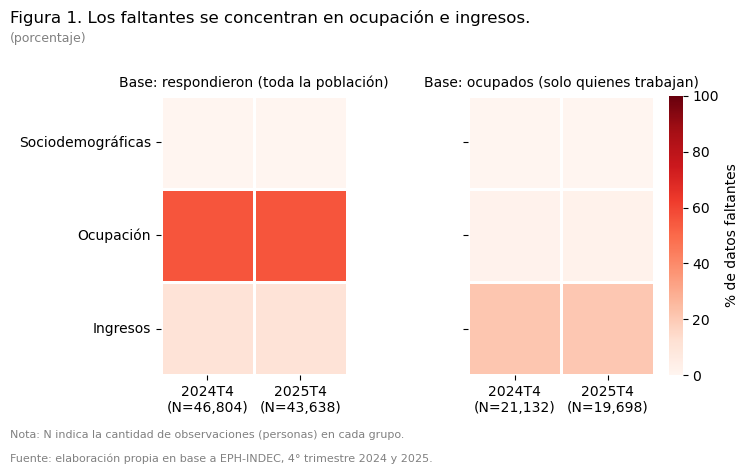

In [33]:
# Inciso 7: heatmap de faltantes AGRUPADO por tipo de variable (Schwabish: reducir clutter)

# Definimos grupos de variables según su naturaleza
grupos = {
    'Sociodemográficas': ['CH04','CH06','CH07','CH08','NIVEL_ED'],
    'Ocupación': ['EMPLEO','SECTOR','PP04C','PP04D_COD','PP05I','PP05K','PP04A','PP3E_TOT','INTENSI'],
    'Ingresos': ['P21','P47T'],
}

def faltantes_por_grupo(df):
    """% promedio de faltantes de cada grupo, por año."""
    filas = {}
    for nombre, vars_g in grupos.items():
        filas[nombre] = df.groupby('ANO4')[vars_g].apply(lambda x: x.isna().mean().mean() * 100)
    return pd.DataFrame(filas).T

tabla_resp = faltantes_por_grupo(respondieron)
tabla_ocup = faltantes_por_grupo(ocupados)

# Renombramos columnas con el N incluido (Schwabish: integrar texto y gráfico)
n_resp = respondieron.groupby('ANO4').size()
n_ocup = ocupados.groupby('ANO4').size()
tabla_resp.columns = [f'2024T4\n(N={n_resp[2024]:,})', f'2025T4\n(N={n_resp[2025]:,})']
tabla_ocup.columns = [f'2024T4\n(N={n_ocup[2024]:,})', f'2025T4\n(N={n_ocup[2025]:,})']

# Dos paneles, mismos grupos, para comparar las dos bases
fig, axes = plt.subplots(1, 2, figsize=(7.6, 4), sharey=True)
sns.heatmap(tabla_resp, annot=False, cmap='Reds', vmin=0, vmax=100,
            cbar=False, ax=axes[0], linewidths=1, square=True)
axes[0].set_title("Base: respondieron (toda la población)", fontsize=10)
axes[0].set_ylabel(""); axes[0].tick_params(axis='y', rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontweight='normal')
sns.heatmap(tabla_ocup, annot=False, cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '% de datos faltantes'}, ax=axes[1], linewidths=1, square=True)
axes[1].set_title("Base: ocupados (solo quienes trabajan)", fontsize=10)
axes[1].set_ylabel("")
# Título a la izquierda + subtítulo aclaratorio en gris
fig.suptitle("Figura 1. Los faltantes se concentran en ocupación e ingresos.",
             fontsize=12, x=0.02, ha='left', y=1.05)
fig.text(0.02, 0.97, "(porcentaje)", fontsize=9, color='gray', ha='left')
# Fuente al pie
fig.text(0.02, -0.08,
         "Nota: N indica la cantidad de observaciones (personas) en cada grupo.\n\nFuente: elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.",
         fontsize=8, color='gray', ha='left')
plt.subplots_adjust(wspace=0.05)
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
plt.savefig('output/fig1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Tabla 1.** Porcentaje de valores faltantes por variable, base y año.

In [34]:
# Tabla detallada de faltantes por variable (respaldo del heatmap agrupado)
det_resp = respondieron.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100).T
det_ocup = ocupados.groupby('ANO4')[vars_interes].apply(lambda x: x.isna().mean() * 100).T

det_resp.index = [etiquetas[v] for v in det_resp.index]
det_ocup.index = [etiquetas[v] for v in det_ocup.index]

tabla_detalle = pd.concat(
    [det_resp, det_ocup],
    axis=1,
    keys=['respondieron', 'ocupados']
).round(1)

# Damos formato: nombres de variables a la izquierda, números centrados
tabla_detalle.style \
    .format('{:.1f}') \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        {'selector': 'th.col_heading', 'props': [('text-align', 'center')]},
    ])

*Fuente: Elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.*

---
## Parte II: Análisis descriptivo

### Inciso 8. Matriz de correlación

Las variables categóricas entran a la matriz a través de sus dummies del inciso 5 (una correlación sobre códigos arbitrarios como los de CH08 no significa nada); edad y nivel educativo entran crudas por tener orden natural, y los ingresos entran en términos reales.

De la lista pedida por la consigna, ESTADO no aparece en la matriz por una razón mecánica: la base `ocupados` se construyó reteniendo solo ESTADO = 1, así que la variable es constante y su correlación con cualquier otra no está definida (desvío cero). El resto de las variables solicitadas está presente, las categóricas a través de sus dummies.

In [35]:
# Variables para la matriz de correlación:
# SECTOR, ESTADO, CAT_OCUP, P21, P47T, NIVEL_ED, CH04, CH06, CH07, CH08
# Las categóricas van con sus DUMMIES (inciso 5), no crudas.

# Vemos qué columnas dummy tenemos creadas en ocupados
print([c for c in ocupados.columns if c in [
    'mujer','en_pareja','sin_cobertura','patron','cuenta_propia',
    'asalariado','fam_sin_remun','sector_privado','subocupado']])

['mujer', 'en_pareja', 'sin_cobertura', 'patron', 'cuenta_propia', 'asalariado', 'fam_sin_remun', 'sector_privado', 'subocupado']


In [36]:
# Inciso 8
# Traducimos las categóricas a sus dummies; las numéricas/ordinales van crudas
vars_corr = [
    'CH06',            # edad (numérica, orden natural)
    'nivel_ed_ord',    # nivel educativo (ordinal recodificado: sin instrucción = 0)
    'P21_real',        # ingreso ocupación principal (real)
    'P47T_real',       # ingreso total (real)
    'mujer',           # sexo (dummy)
    'en_pareja',       # estado civil (dummy)
    'sin_cobertura',   # cobertura médica (dummy)
    'sector_informal',  # SECTOR (formal/informal de la unidad económica)
    'patron',          # categoría ocupacional (dummies)
    'cuenta_propia',
    'fam_sin_remun',
]

print("Variables en la matriz:", len(vars_corr))
print(vars_corr)

Variables en la matriz: 11
['CH06', 'nivel_ed_ord', 'P21_real', 'P47T_real', 'mujer', 'en_pareja', 'sin_cobertura', 'sector_informal', 'patron', 'cuenta_propia', 'fam_sin_remun']


In [37]:
# Etiquetas legibles para la matriz
etiquetas_corr = {
    'CH06': 'Edad', 'nivel_ed_ord': 'Nivel educ.', 'P21_real': 'Ing. ocup. ppal.',
    'P47T_real': 'Ing. total', 'mujer': 'Mujer', 'en_pareja': 'En pareja',
    'sin_cobertura': 'Sin cobertura', 'sector_informal': 'Sector informal',
    'patron': 'Patrón', 'cuenta_propia': 'Cuentapropia', 'fam_sin_remun': 'Fam. sin remun.',
}

corr_2024 = ocupados[ocupados['ANO4'] == 2024][vars_corr].corr().rename(index=etiquetas_corr, columns=etiquetas_corr)
corr_2025 = ocupados[ocupados['ANO4'] == 2025][vars_corr].corr().rename(index=etiquetas_corr, columns=etiquetas_corr)

corr_2024.round(2)

,Edad,Nivel educ.,Ing. ocup. ppal.,Ing. total,Mujer,En pareja,Sin cobertura,Sector informal,Patrón,Cuentapropia,Fam. sin remun.
Edad,1.00,-0.06,0.12,0.17,-0.00,0.25,-0.22,-0.04,0.11,0.12,-0.02
Nivel educ.,-0.06,1.00,0.29,0.30,0.19,-0.01,-0.33,-0.29,0.03,-0.10,-0.02
Ing. ocup. ppal.,0.12,0.29,1.00,0.92,-0.15,0.15,-0.33,-0.30,0.13,-0.16,-0.08
Ing. total,0.17,0.30,0.92,1.00,-0.10,0.13,-0.34,-0.28,0.13,-0.12,-0.07
Mujer,-0.00,0.19,-0.15,-0.10,1.00,-0.08,-0.06,-0.10,-0.07,-0.04,0.02
En pareja,0.25,-0.01,0.15,0.13,-0.08,1.00,-0.15,-0.05,0.07,0.04,-0.00
Sin cobertura,-0.22,-0.33,-0.33,-0.34,-0.06,-0.15,1.00,0.52,-0.03,0.23,0.03
Sector informal,-0.04,-0.29,-0.30,-0.28,-0.10,-0.05,0.52,1.00,0.00,0.57,0.07
Patrón,0.11,0.03,0.13,0.13,-0.07,0.07,-0.03,0.00,1.00,-0.11,-0.01
Cuentapropia,0.12,-0.10,-0.16,-0.12,-0.04,0.04,0.23,0.57,-0.11,1.00,-0.04


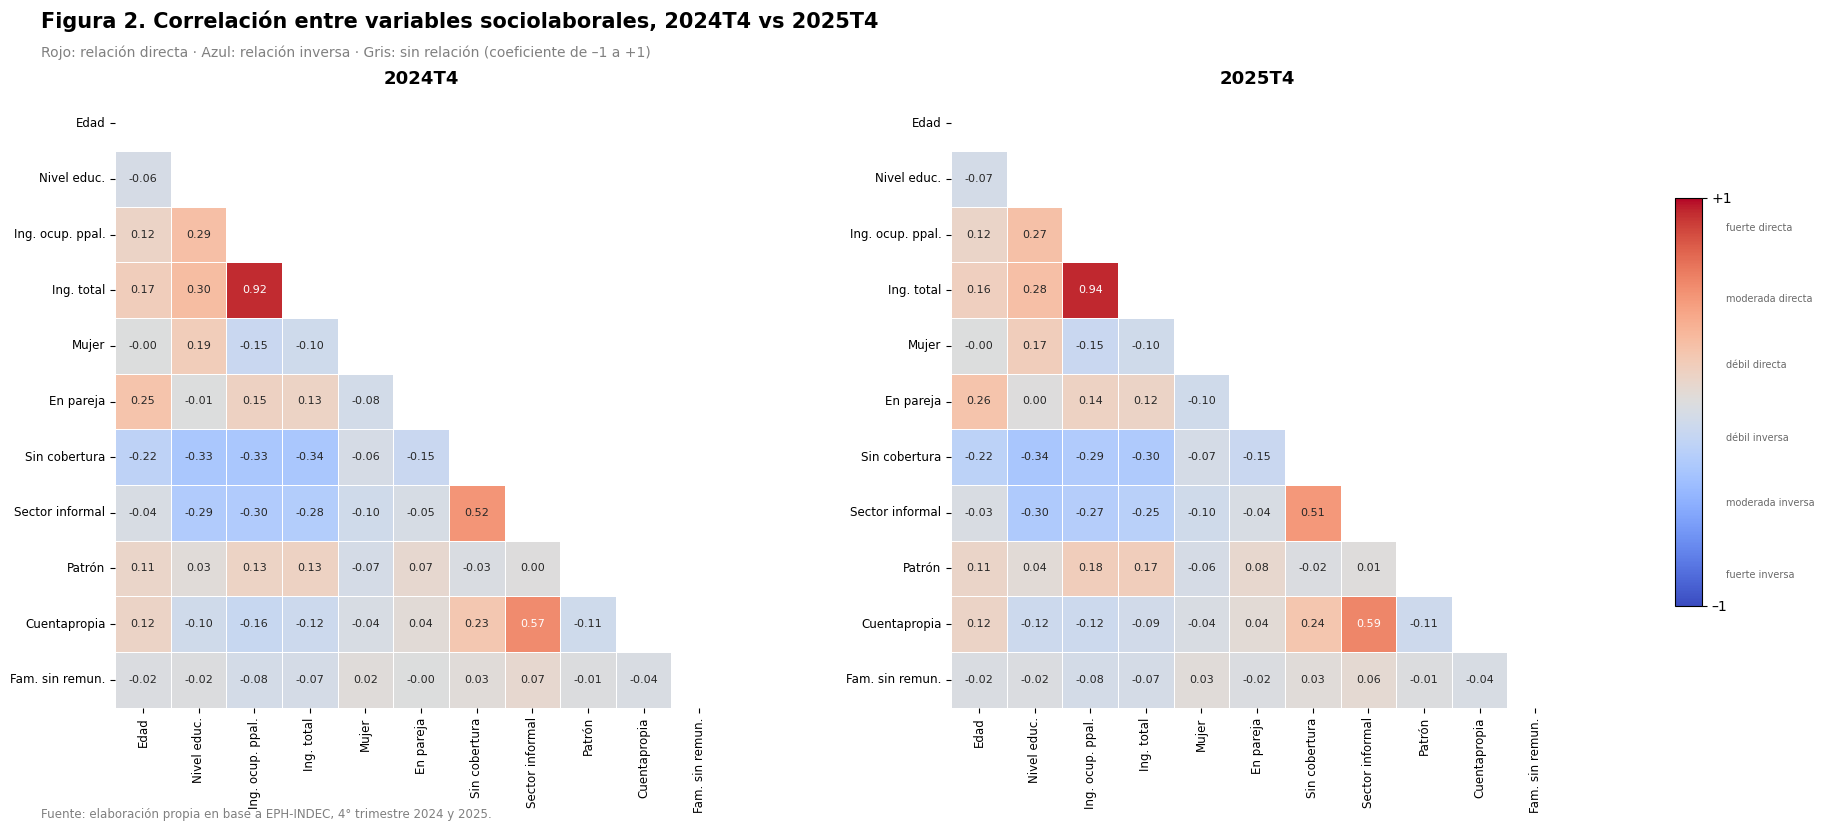

In [38]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(19, 8.5))

mascara24 = np.triu(corr_2024)
mascara25 = np.triu(corr_2025)

sns.heatmap(corr_2024, vmin=-1, vmax=1, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mascara24, linewidths=0.5, square=True,
            cbar=False, annot_kws={'fontsize': 8}, ax=axes[0])
axes[0].set_title("2024T4", fontsize=13, fontweight='bold', pad=8)
axes[0].tick_params(labelsize=8.5)

sns.heatmap(corr_2025, vmin=-1, vmax=1, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mascara25, linewidths=0.5, square=True,
            cbar=False, annot_kws={'fontsize': 8}, ax=axes[1])
axes[1].set_title("2025T4", fontsize=13, fontweight='bold', pad=8)
axes[1].tick_params(labelsize=8.5)

# Barra de color aparte
cbar_ax = fig.add_axes([0.92, 0.28, 0.014, 0.48])
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(-1, 1))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['–1', '+1'])
for y, txt in [(0.85,'fuerte directa'),(0.5,'moderada directa'),(0.18,'débil directa'),
               (-0.18,'débil inversa'),(-0.5,'moderada inversa'),(-0.85,'fuerte inversa')]:
    cbar.ax.text(1.9, y, txt, transform=cbar.ax.get_yaxis_transform(),
                 fontsize=7, color='dimgray', va='center', ha='left')

# Títulos y fuente, ubicados en coordenadas de figura con márgenes amplios
fig.text(0.06, 0.96, "Figura 2. Correlación entre variables sociolaborales, 2024T4 vs 2025T4",
         fontsize=15, fontweight='bold', ha='left')
fig.text(0.06, 0.925, "Rojo: relación directa · Azul: relación inversa · Gris: sin relación (coeficiente de –1 a +1)",
         fontsize=10, color='gray', ha='left')
fig.text(0.06, 0.03, "Fuente: elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.",
         fontsize=8.5, color='gray', ha='left')

# Márgenes: dejo espacio arriba (título), abajo (fuente) y derecha (barra)
plt.subplots_adjust(top=0.88, bottom=0.16, left=0.06, right=0.90, wspace=0.10)
plt.savefig('output/fig2_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

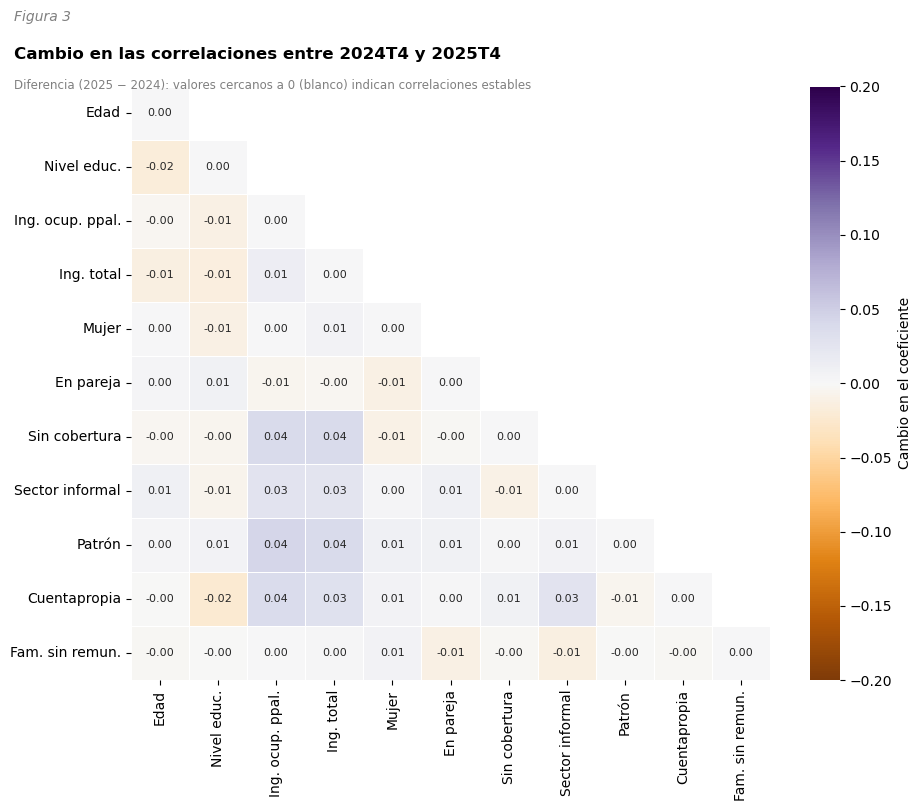

In [39]:
import numpy as np

# Matriz de diferencias: cuánto cambió cada correlación de 2024 a 2025
dif = corr_2025 - corr_2024
mascara = np.triu(dif)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
hm = sns.heatmap(dif, vmin=-0.2, vmax=0.2, annot=True, fmt='.2f',
                 cmap='PuOr', mask=mascara, linewidths=0.5,
                 cbar=True, annot_kws={'fontsize': 8}, ax=ax, center=0)

fig.text(0.02, 1.06, "Figura 3", fontsize=10, style='italic', color='gray', ha='left')
fig.text(0.02, 1.01, "Cambio en las correlaciones entre 2024T4 y 2025T4", fontsize=12, fontweight='bold', ha='left')
fig.text(0.02, 0.97, "Diferencia (2025 − 2024): valores cercanos a 0 (blanco) indican correlaciones estables",
         fontsize=8.5, color='gray', ha='left')

cbar = hm.collections[0].colorbar
cbar.set_label('Cambio en el coeficiente')

plt.tight_layout()
plt.savefig('output/fig3_cambio_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

La estructura de correlaciones es casi idéntica entre los dos años (Figura 3: ninguna diferencia supera 0,05 en valor absoluto), lo que da confianza en que la comparación 2024-2025 no está distorsionada por cambios en la composición de la muestra. Tres relaciones concentran la lectura económica. Primero, P21 y P47T correlacionan 0,92-0,94: para los ocupados, el ingreso total es esencialmente el ingreso laboral principal. Segundo, la falta de cobertura médica se asocia negativamente con el nivel educativo y con ambos ingresos (coeficientes entre −0,29 y −0,34), el rastro clásico de la informalidad. Tercero, trabajar en el sector informal de la unidad económica se asocia con el cuentapropismo (0,57-0,59) y con la falta de cobertura (0,51-0,52), un adelanto de lo que la Parte III mide con la definición de Maurizio & Monsalvo.

### Inciso 9. Estadística descriptiva

Antes de la tabla se limpian los códigos de no respuesta que el diseño de registro documenta para las variables de ocupación (99 en tamaño del establecimiento, 9 en sector/empleo/aportes/factura, 999 en horas), para que no contaminen promedios ni percentiles. Las variables numéricas y las categóricas reciben tratamiento separado: describir con media y desvío una variable de códigos no tiene interpretación.

In [40]:
# Verificación previa a la descriptiva: los códigos Ns/Nr ya fueron
# convertidos a NaN en el inciso 2.b, sobre la base completa.
for v in ['PP04C', 'SECTOR', 'EMPLEO', 'PP05I', 'PP05K', 'PP3E_TOT']:
    quedan = ocupados[v].isin([9, 99, 999]).sum()
    print(f"{v}: {ocupados[v].isna().sum():>5} NaN | códigos Ns/Nr remanentes: {quedan}")


PP04C:  5403 NaN | códigos Ns/Nr remanentes: 2998
SECTOR:  1607 NaN | códigos Ns/Nr remanentes: 0
EMPLEO:    26 NaN | códigos Ns/Nr remanentes: 0
PP05I:    18 NaN | códigos Ns/Nr remanentes: 0
PP05K:   148 NaN | códigos Ns/Nr remanentes: 0
PP3E_TOT:    87 NaN | códigos Ns/Nr remanentes: 343


**Tabla 2.** Estadística descriptiva de las variables numéricas

In [41]:
# Tabla 2: descriptiva de las variables NUMÉRICAS, por año
vars_numericas = ['CH06', 'P21_real', 'P47T_real', 'PP04C', 'PP3E_TOT']
etiquetas_num = {
    'CH06': 'Edad (años)',
    'P21_real': 'Ingreso ocup. principal ($)',
    'P47T_real': 'Ingreso total ($)',
    'PP04C': 'Tamaño del establecimiento (tramo)',
    'PP3E_TOT': 'Horas trabajadas semanales',
}

def descriptiva(df):
    t = df[vars_numericas].describe(percentiles=[.01, .25, .50, .75, .99]).round(2).T
    t = t.rename(index=etiquetas_num)
    return t.rename(columns={'count':'N', 'mean':'Promedio', 'std':'Desvío',
                             'min':'Mín', '1%':'p1', '25%':'p25', '50%':'p50',
                             '75%':'p75', '99%':'p99', 'max':'Máx'})

# Un panel por año: los ingresos están en pesos constantes de 2025T4,
# lo que permite comparar niveles reales entre trimestres
tabla2 = pd.concat({
    '2024T4': descriptiva(ocupados[ocupados['ANO4'] == 2024]),
    '2025T4': descriptiva(ocupados[ocupados['ANO4'] == 2025]),
})

tabla2.style.format('{:,.0f}').set_properties(**{'text-align':'center'}) \
    .set_table_styles([{'selector':'th.row_heading','props':[('text-align','left')]}])


*Fuente: elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.*

**Tabla 3.** Distribución de frecuencias de las principales variables categóricas

In [42]:
# Tabla 3: frecuencias de las variables CATEGÓRICAS (tratamiento correcto para categóricas)
# Mapeos de códigos a etiquetas legibles (según diseño de registro EPH)
mapeos = {
    'CH04': ({1:'Varón', 2:'Mujer'}, 'Sexo'),
    'CAT_OCUP': ({1:'Patrón', 2:'Cuenta propia', 3:'Obrero/empleado', 4:'Fam. sin remun.'}, 'Categoría ocupacional'),
    'NIVEL_ED': ({1:'Primaria incompleta', 2:'Primaria completa', 3:'Secundaria incompleta',
                  4:'Secundaria completa', 5:'Superior incompleta', 6:'Superior completa', 7:'Sin instrucción'}, 'Nivel educativo'),
    'SECTOR': ({1:'Formal', 2:'Informal', 3:'Hogares'}, 'Sector'),
    'INTENSI': ({1:'Subocupado', 2:'Ocupado pleno', 3:'Sobreocupado', 4:'No trabajó'}, 'Intensidad'),
    'PP04A': ({1:'Estatal', 2:'Privado', 3:'Otro'}, 'Ámbito'),
}

# Armamos una tabla de frecuencias (conteo y %) para cada una
for var, (mapa, nombre) in mapeos.items():
    conteo = ocupados[var].map(mapa).value_counts()
    porc = (ocupados[var].map(mapa).value_counts(normalize=True) * 100).round(1)
    tabla = pd.DataFrame({'Casos': conteo, '%': porc})
    print(f"\n=== {nombre} ({var}) ===")
    print(tabla.to_string())


=== Sexo (CH04) ===
       Casos     %
CH04              
Varón  22361  54.8
Mujer  18469  45.2

=== Categoría ocupacional (CAT_OCUP) ===
                 Casos     %
CAT_OCUP                    
Obrero/empleado  29235  71.6
Cuenta propia     9933  24.3
Patrón            1478   3.6
Fam. sin remun.    184   0.5

=== Nivel educativo (NIVEL_ED) ===
                       Casos     %
NIVEL_ED                          
Secundaria completa    13211  32.4
Superior completa       9797  24.0
Secundaria incompleta   6461  15.8
Superior incompleta     5877  14.4
Primaria completa       4358  10.7
Primaria incompleta     1055   2.6
Sin instrucción           71   0.2

=== Sector (SECTOR) ===
          Casos     %
SECTOR               
Formal    27025  68.9
Informal   9417  24.0
Hogares    2781   7.1

=== Intensidad (INTENSI) ===
               Casos     %
INTENSI                   
Ocupado pleno  23704  58.1
Sobreocupado   11848  29.0
Subocupado      4642  11.4
No trabajó       636   1.6

=== Ámbi

---
## Parte III: Conociendo la informalidad laboral

### Inciso 10. Construcción del indicador: *informal self-employed*

Seguimos la definición operativa de Maurizio & Monsalvo (2021, Box 1), que clasifica a los trabajadores independientes según un criterio productivo (capacidad del emprendimiento) y no según el registro tributario. Las decisiones tomadas, con las variables del diseño de registro de la EPH:

1. **Universo:** patrones, cuentapropistas y familiares sin remuneración (`CAT_OCUP` ∈ {1, 2, 4}), excluyendo a quienes trabajan en el sector estatal (`PP04A` = 1), porque el sector público queda fuera del sector informal en esta metodología. Los asalariados (`CAT_OCUP` = 3) tienen su propia definición de informalidad y no integran este universo.
2. **Patrones:** formales si el establecimiento tiene 6 empleados o más (`PP04C` ≥ 6); informales con 5 o menos.
3. **Cuentapropistas:** formales solo si son profesionales, aproximado con superior universitaria completa (`NIVEL_ED` = 6). La condición es de igualdad estricta porque los códigos 7 (sin instrucción) y 9 (Ns/Nr) no pertenecen a la escala ordinal 1-6.
4. **Familiares sin remuneración:** informales en todos los casos.
5. **Faltantes:** la formalidad exige evidencia positiva (tamaño del establecimiento o título universitario). Los casos sin dato en `PP04C` o `NIVEL_ED` quedan en la categoría residual, es decir, informales. Es la lectura consistente con la construcción de Maurizio & Monsalvo, donde lo formal se acredita y lo informal es el resto.

**Apéndice A (inciso 9).** La consigna pide la descriptiva de todas las variables seleccionadas. La tabla siguiente la reporta para las 20, con los estadísticos solicitados. Para las variables codificadas (CAT_OCUP, SECTOR, PP04D_COD, AGLOMERADO y demás), media y percentiles se calculan sobre códigos arbitrarios y no tienen interpretación económica: la lectura sustantiva de esas variables es la Tabla 3. Se reportan igual por completitud.

In [43]:
# Apéndice A: descriptiva de las 20 variables seleccionadas, por año
estadisticos = ['count','mean','std','min','1%','25%','50%','75%','99%','max']
nombres = {'count':'N','mean':'Promedio','std':'Desvío','min':'Mín','1%':'p1',
           '25%':'p25','50%':'p50','75%':'p75','99%':'p99','max':'Máx'}

def descriptiva_full(df):
    t = df[vars_interes].describe(percentiles=[.01, .25, .50, .75, .99]).T[estadisticos]
    return t.rename(columns=nombres).rename(index=etiquetas)

apendice_a = pd.concat({
    '2024T4': descriptiva_full(ocupados[ocupados['ANO4'] == 2024]),
    '2025T4': descriptiva_full(ocupados[ocupados['ANO4'] == 2025]),
})

apendice_a.style.format('{:,.2f}').set_properties(**{'text-align':'center'}) \
    .set_table_styles([{'selector':'th.row_heading','props':[('text-align','left')]}])


Dos lecturas salen de la tabla. La primera es distributiva: el ingreso real de la ocupación principal creció entre trimestres, pero no de manera pareja. El p25 y la mediana subieron 21,8% (de $328.527 a $400.000 y de $657.053 a $800.000, en pesos de 2025T4), la media 10,8% y el p99 apenas 1,5%. La mejora se concentró en la base y el medio de la distribución, con la cola alta casi estancada; establecerlo con rigor exigiría inferencia acorde al diseño muestral de la EPH, que excede este trabajo. La segunda lectura es de calidad del dato: la mediana queda muy por debajo de la media en ambos años, la asimetría típica de las distribuciones de ingreso, y los percentiles de 2025 caen en cifras redondas ($400.000, $800.000, $1.200.000), huella del redondeo en la declaración que se retoma al discutir limitaciones en la Parte III. Una precisión sobre el tamaño del establecimiento: PP04C se releva en tramos (los códigos 1 a 5 son cantidades exactas de personas; del 6 en adelante son rangos, hasta el 12 = más de 500), así que su media y sus percentiles se leen como códigos de tramo, no como personas.

In [44]:
# INCISO 10 - Construcción de la informalidad (self-employed, Maurizio & Monsalvo)

# Paso 1: universo self-employed = patrones, cuentapropistas y familiares
# CAT_OCUP: 1=Patrón, 2=Cuenta propia, 4=Fam. sin remuneración
# Excluimos sector público (Maurizio: el sector público queda fuera del sector informal)
# PP04A: 1=estatal, 2=privado, 3=otro → nos quedamos con NO estatales

self_emp = ocupados[
    (ocupados['CAT_OCUP'].isin([1, 2, 4])) &   # self-employed
    (ocupados['PP04A'] != 1)                    # excluye estatales
].copy()

print(f"Self-employed (excluyendo sector público): {len(self_emp)} casos")
print()
print("Composición por categoría:")
print(self_emp['CAT_OCUP'].value_counts().sort_index())
print("1=Patrón, 2=Cuenta propia, 4=Fam. sin remun.")
print()
print("Por año:")
print(self_emp['ANO4'].value_counts().sort_index())

Self-employed (excluyendo sector público): 11595 casos

Composición por categoría:
CAT_OCUP
1    1478
2    9933
4     184
Name: count, dtype: int64
1=Patrón, 2=Cuenta propia, 4=Fam. sin remun.

Por año:
ANO4
2024    5840
2025    5755
Name: count, dtype: int64


In [45]:
# Paso 2: construir la variable informal según Maurizio & Monsalvo (Box 1)
# - Patrón (1): formal si el establecimiento tiene 6 o más personas (PP04C >= 6).
# - Cuentapropista (2): formal solo si es profesional, aproximado por superior
#   universitaria completa. La condición es de IGUALDAD estricta (NIVEL_ED == 6)
#   porque el 7 ("sin instrucción") no pertenece a la escala ordinal 1-6.
# - Familiar sin remuneración (4): informal en todos los casos.
# Los casos con Ns/Nr en la variable que define su criterio quedan SIN CLASIFICAR
# (NaN): no se imputan, para no forzar el resultado en ninguna dirección.

def clasificar_informal(row):
    if row['CAT_OCUP'] == 1:                      # Patrón
        if pd.isna(row['PP04C']):
            return np.nan
        return 0 if row['PP04C'] >= 6 else 1
    elif row['CAT_OCUP'] == 2:                    # Cuentapropista
        if pd.isna(row['NIVEL_ED']):
            return np.nan
        return 0 if row['NIVEL_ED'] == 6 else 1
    elif row['CAT_OCUP'] == 4:                    # Familiar sin remuneración
        return 1
    return np.nan

self_emp['informal'] = self_emp.apply(clasificar_informal, axis=1)

print("Distribución formal/informal (1 = Informal, 0 = Formal):")
print(self_emp['informal'].value_counts(dropna=False))
print()
print("Sin clasificar (Ns/Nr en PP04C):", int(self_emp['informal'].isna().sum()),
      "por año:", self_emp[self_emp['informal'].isna()]['ANO4'].value_counts().sort_index().to_dict())
print(f"% Informal (sin ponderar): {self_emp['informal'].mean()*100:.1f}%")


Distribución formal/informal (1 = Informal, 0 = Formal):
informal
1.0    9388
0.0    2154
NaN      53
Name: count, dtype: int64

Sin clasificar (Ns/Nr en PP04C): 53 por año: {2024: 30, 2025: 23}
% Informal (sin ponderar): 81.3%


In [46]:
# Validación: ver informal/formal por categoría ocupacional
print(pd.crosstab(self_emp['CAT_OCUP'], self_emp['informal'],
                  margins=True, margins_name='Total'))
print("\nFilas: 1=Patrón, 2=Cuentapropia, 4=Familiar | Columnas: 0=Formal, 1=Informal")

informal   0.0   1.0  Total
CAT_OCUP                   
1          339  1086   1425
2         1815  8118   9933
4            0   184    184
Total     2154  9388  11542

Filas: 1=Patrón, 2=Cuentapropia, 4=Familiar | Columnas: 0=Formal, 1=Informal


In [47]:
# Diagnósticos que respaldan las decisiones del indicador

# 1. ¿El corte de PP04C en 6 es aplicable? Distribución entre patrones.
print("PP04C entre patrones (self-employed):")
print(self_emp[self_emp['CAT_OCUP'] == 1]['PP04C'].value_counts(dropna=False).sort_index())

# 2. ¿Por qué las mujeres independientes resultan menos informales?
#    Si la brecha es composicional, la proporción de universitarias completas
#    entre las cuentapropistas debe superar a la de los varones.
cp = self_emp[self_emp['CAT_OCUP'] == 2]
print("\n% con superior universitaria completa (NIVEL_ED == 6), cuentapropistas:")
print((cp.groupby('CH04')['NIVEL_ED'].apply(lambda x: (x == 6).mean()) * 100).round(1))
print("1 = Varón, 2 = Mujer")


PP04C entre patrones (self-employed):
PP04C
2.0     442
3.0     332
4.0     201
5.0     111
6.0     190
7.0      76
8.0      27
9.0      30
10.0     10
11.0      4
12.0      2
NaN      53
Name: count, dtype: int64

% con superior universitaria completa (NIVEL_ED == 6), cuentapropistas:
CH04
1    14.0
2    24.3
Name: NIVEL_ED, dtype: float64
1 = Varón, 2 = Mujer


In [48]:
# Validación externa: contraste con la clasificación EMPLEO del INDEC
# Según el diseño de registro, EMPLEO = 1 (formal), 2 (informal); el 9 (Ns/Nr)
# ya fue convertido a NaN en el inciso 9.
# La coincidencia no debería ser total: el INDEC clasifica por registración
# efectiva y Maurizio & Monsalvo por proxies productivos (tamaño y profesión).

valid = self_emp.dropna(subset=['EMPLEO']).copy()
valid['informal_indec'] = (valid['EMPLEO'] == 2).astype(int)

print("Tabla de contingencia (propia vs INDEC):")
print(pd.crosstab(valid['informal'], valid['informal_indec'],
                  rownames=['Propia'], colnames=['INDEC']))
print()
coincidencia = (valid['informal'] == valid['informal_indec']).mean() * 100
print(f"Coincidencia simple (sin ponderar): {coincidencia:.1f}%")


Tabla de contingencia (propia vs INDEC):
INDEC      0     1
Propia            
0.0     1624   525
1.0     2737  6630

Coincidencia simple (sin ponderar): 71.3%


In [49]:
# Tabla de doble entrada: % informal/formal por sexo y año (PONDERADA con PONDERA)

def tabla_informalidad(df, año):
    sub = df[df['ANO4'] == año]
    resultados = {}
    # Total
    total = sub.groupby('informal')['PONDERA'].sum()
    resultados['Total'] = (total / total.sum() * 100).round(1)
    # Mujeres (CH04==2)
    muj = sub[sub['CH04']==2].groupby('informal')['PONDERA'].sum()
    resultados['Mujeres'] = (muj / muj.sum() * 100).round(1)
    # Varones (CH04==1)
    var = sub[sub['CH04']==1].groupby('informal')['PONDERA'].sum()
    resultados['Varones'] = (var / var.sum() * 100).round(1)
    tabla = pd.DataFrame(resultados)
    tabla.index = ['Formal', 'Informal']
    return tabla

print("=== 2024 ===")
print(tabla_informalidad(self_emp, 2024))
print("\n=== 2025 ===")
print(tabla_informalidad(self_emp, 2025))

=== 2024 ===
          Total  Mujeres  Varones
Formal     21.4     26.0     18.4
Informal   78.6     74.0     81.6

=== 2025 ===
          Total  Mujeres  Varones
Formal     19.8     24.3     16.8
Informal   80.2     75.7     83.2


**Tabla 4.** Trabajadores formales e informales del sector independiente, por sexo y año (porcentaje)

In [50]:
# Tabla 4 final: informalidad por sexo y año, presentada de forma integrada

def tabla_informalidad(df, año):
    sub = df[df['ANO4'] == año]
    res = {}
    for col, filtro in [('Total', sub), ('Mujeres', sub[sub['CH04']==2]), ('Varones', sub[sub['CH04']==1])]:
        s = filtro.groupby('informal')['PONDERA'].sum()
        res[col] = (s / s.sum() * 100).round(1)
    t = pd.DataFrame(res)
    t.index = ['Formal', 'Informal']
    return t

t2024 = tabla_informalidad(self_emp, 2024)
t2025 = tabla_informalidad(self_emp, 2025)

# Unimos los dos años con un nivel de columna que los identifique
tabla4 = pd.concat({'2024T4': t2024, '2025T4': t2025}, axis=1)
tabla4

2024T4                 2025T4                
          Total Mujeres Varones  Total Mujeres Varones
Formal     21.4    26.0    18.4   19.8    24.3    16.8
Informal   78.6    74.0    81.6   80.2    75.7    83.2

*Nota: porcentajes ponderados por el factor de expansión (PONDERA). Fuente: elaboración propia en base a EPH-INDEC, 4° trimestre 2024 y 2025.*

Cuatro de cada cinco independientes son informales: 78,6% en 2024T4 y 80,2% en 2025T4, un aumento de 1,6 puntos entre trimestres y una proporción consistente con la que Maurizio & Monsalvo reportan para Argentina. Las mujeres presentan menor informalidad que los varones en ambos años (74,0% contra 81,6% en 2024; 75,7% contra 83,2% en 2025). El patrón puede resultar contraintuitivo, pero es composicional: la definición clasifica como formales a los cuentapropistas profesionales, y la proporción con universitaria completa entre las cuentapropistas mujeres (24,3%) supera con holgura a la de los varones (14,0%), como muestra el diagnóstico previo. La brecha refleja la composición educativa del cuentapropismo femenino, no una ventaja general de las mujeres en el mercado de trabajo independiente. Como validación externa, la clasificación construida coincide en 71,3% (proporción simple, sin ponderar) con la variable EMPLEO del INDEC. La divergencia es esperable y tiene dirección: el desacuerdo se concentra en 2.737 casos que el criterio productivo marca como informales pero que el INDEC registra como formales, porque el instituto clasifica por registración efectiva mientras el paper usa proxies de capacidad productiva (tamaño y profesionalidad).

### Inciso 11. Distribución del ingreso de formales e informales

Para el gráfico se usan los ingresos reales (pesos de 2025T4), solo valores positivos y recortados entre los percentiles 1 y 99 de cada variable, para que los outliers no aplasten la escala. Los histogramas y kernels se presentan con `common_norm=False`: cada grupo integra a 1 por separado, de modo que las formas son comparables aunque los informales cuadrupliquen en cantidad a los formales. El gráfico agrupa ambos trimestres: como los ingresos de 2024 ya están expresados en pesos de 2025T4, las observaciones son comparables y el agrupamiento gana precisión en el grupo formal, que es chico; la comparación entre años queda a cargo de la Tabla 4.

In [51]:
# INCISO 11 - Preparación de datos para el gráfico de distribuciones
# Excluimos ingresos <= 0 y recortamos outliers (percentil 1-99) para visualizar mejor

# Etiqueta legible de formal/informal
self_emp['grupo'] = self_emp['informal'].map({0: 'Formal', 1: 'Informal'})

def preparar_ingreso(df, col):
    # Solo ingresos positivos
    d = df[df[col] > 0].copy()
    # Recorte de outliers: entre percentil 1 y 99
    p1, p99 = d[col].quantile([0.01, 0.99])
    d = d[(d[col] >= p1) & (d[col] <= p99)]
    return d

datos_p21 = preparar_ingreso(self_emp, 'P21_real')
datos_p47 = preparar_ingreso(self_emp, 'P47T_real')

print(f"P21_real: {len(datos_p21)} casos (tras excluir ceros y recortar outliers)")
print(f"P47T_real: {len(datos_p47)} casos")
print()
print("Por grupo (P21):")
print(datos_p21['grupo'].value_counts())
print()
print("Mediana de P21_real por grupo:")
print(datos_p21.groupby('grupo')['P21_real'].median())
print()
print("Mediana de P47T_real por grupo:")
print(datos_p47.groupby('grupo')['P47T_real'].median())


P21_real: 8121 casos (tras excluir ceros y recortar outliers)
P47T_real: 8062 casos

Por grupo (P21):
grupo
Informal    6701
Formal      1410
Name: count, dtype: int64

Mediana de P21_real por grupo:
grupo
Formal      919874.337855
Informal    459937.168927
Name: P21_real, dtype: float64

Mediana de P47T_real por grupo:
grupo
Formal      1.051285e+06
Informal    5.724681e+05
Name: P47T_real, dtype: float64


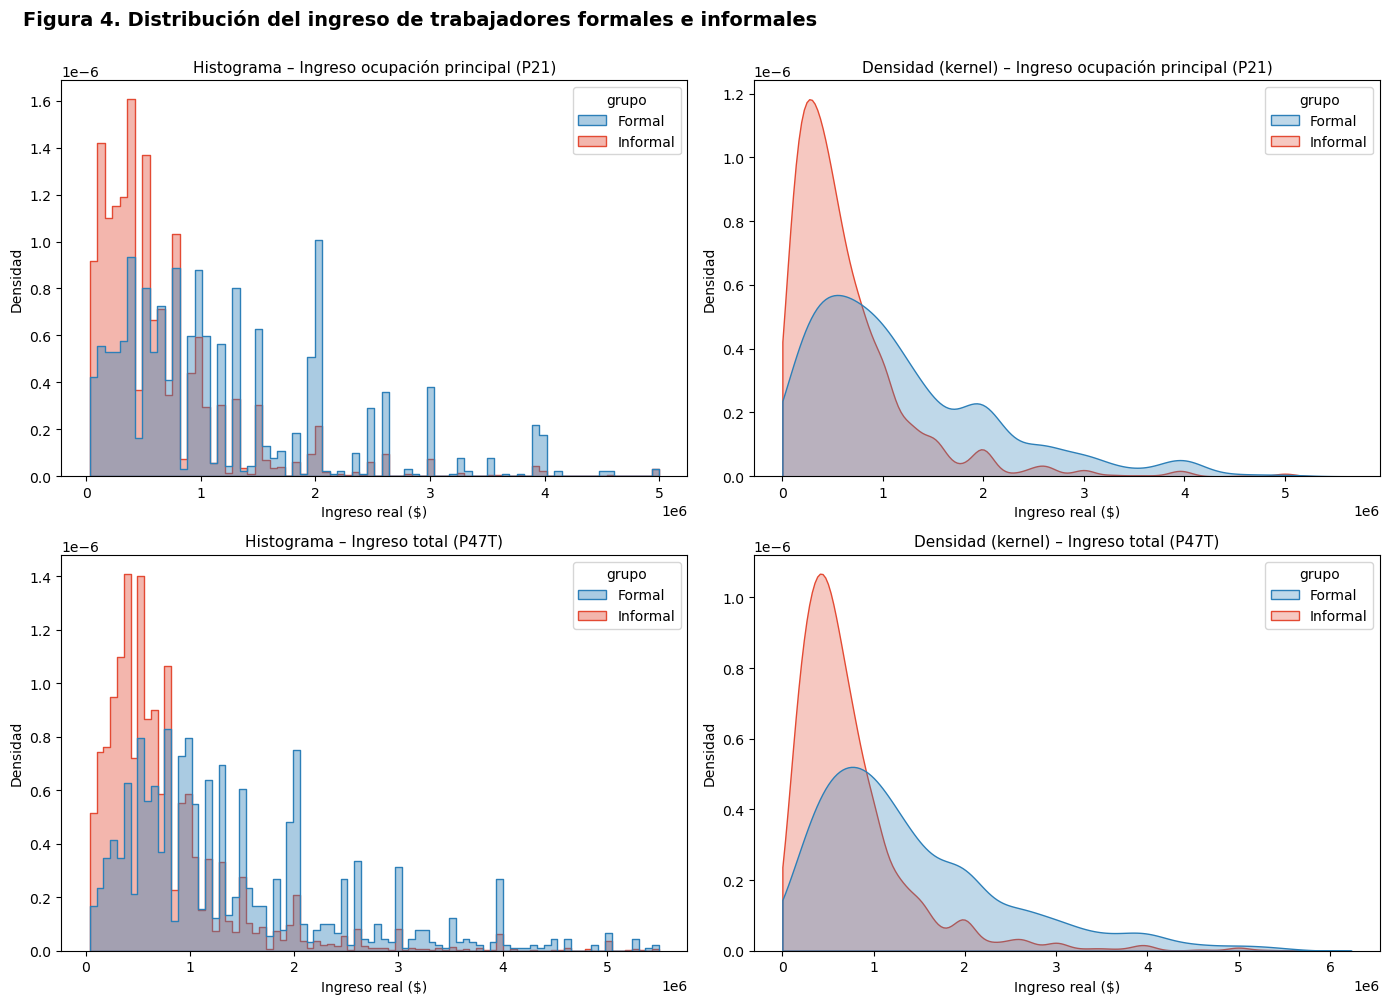

In [52]:
# INCISO 11 - Gráfico de 4 paneles: histograma y kernel de P21 y P47T, formal vs informal

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colores = {'Formal': '#2c7fb8', 'Informal': '#e34a33'}

# Panel 1 (arriba izq): Histograma P21
sns.histplot(data=datos_p21, x='P21_real', hue='grupo', stat='density',
             common_norm=False, element='step', palette=colores, alpha=0.4, ax=axes[0,0])
axes[0,0].set_title("Histograma – Ingreso ocupación principal (P21)", fontsize=11)
axes[0,0].set_xlabel("Ingreso real ($)"); axes[0,0].set_ylabel("Densidad")

# Panel 2 (arriba der): Kernel P21. clip=(0, None) evita que la densidad
# estimada se extienda hacia ingresos negativos, que no existen en los datos
sns.kdeplot(data=datos_p21, x='P21_real', hue='grupo', clip=(0, None),
            common_norm=False, fill=True, palette=colores, alpha=0.3, ax=axes[0,1])
axes[0,1].set_title("Densidad (kernel) – Ingreso ocupación principal (P21)", fontsize=11)
axes[0,1].set_xlabel("Ingreso real ($)"); axes[0,1].set_ylabel("Densidad")

# Panel 3 (abajo izq): Histograma P47T
sns.histplot(data=datos_p47, x='P47T_real', hue='grupo', stat='density',
             common_norm=False, element='step', palette=colores, alpha=0.4, ax=axes[1,0])
axes[1,0].set_title("Histograma – Ingreso total (P47T)", fontsize=11)
axes[1,0].set_xlabel("Ingreso real ($)"); axes[1,0].set_ylabel("Densidad")

# Panel 4 (abajo der): Kernel P47T
sns.kdeplot(data=datos_p47, x='P47T_real', hue='grupo', clip=(0, None),
            common_norm=False, fill=True, palette=colores, alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Densidad (kernel) – Ingreso total (P47T)", fontsize=11)
axes[1,1].set_xlabel("Ingreso real ($)"); axes[1,1].set_ylabel("Densidad")

fig.suptitle("Figura 4. Distribución del ingreso de trabajadores formales e informales",
             fontsize=14, fontweight='bold', x=0.02, ha='left', y=1.00)

plt.tight_layout()
plt.savefig('output/fig4_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

Los cuatro paneles cuentan la misma historia: la distribución de los informales se concentra en un pico agudo de ingresos bajos, con la moda cerca de los $400.000, mientras que la de los formales es más achatada, está desplazada a la derecha y conserva una cola larga. La mediana de P21 de los formales duplica aproximadamente a la de los informales, como reportan las medianas por grupo impresas en la celda de preparación. Al mismo tiempo, ambas colas se superponen: hay informales de ingresos altos y formales de ingresos modestos, la heterogeneidad interna que motiva el enfoque por niveles del paper. Las dos variables de ingreso tienen limitaciones distintas. P21 mide solo la ocupación principal y arrastra una no respuesta cercana al 20% entre ocupados, que difícilmente sea aleatoria: los ingresos altos y los muy informales tienden a no declarar. P47T incluye todas las fuentes, laborales y no laborales, por lo que mezcla el fenómeno de interés (el retorno del trabajo independiente) con transferencias y rentas; su cola derecha es más larga por esa razón. Ninguna captura ingresos subdeclarados, un problema conocido de las encuestas de hogares que golpea con más fuerza en el extremo superior, y los familiares sin remuneración quedan fuera del gráfico por construcción, al no percibir ingreso.

#### Sensibilidad del gráfico a la cantidad de bins y al ancho de banda

Ni el histograma ni la estimación kernel son neutrales a sus parámetros. Con pocos bins el histograma esconde la forma de la distribución; con demasiados, el ruido muestral domina y aparecen picos artificiales (visibles además en los múltiplos redondos: $500.000, $1.000.000, $2.000.000, típicos de ingresos declarados). Con el kernel pasa lo mismo a través del ancho de banda: un `bw_adjust` bajo sobreajusta y uno alto borra la asimetría real entre formales e informales. El panel siguiente muestra los dos extremos y el valor intermedio elegido para la Figura 4.

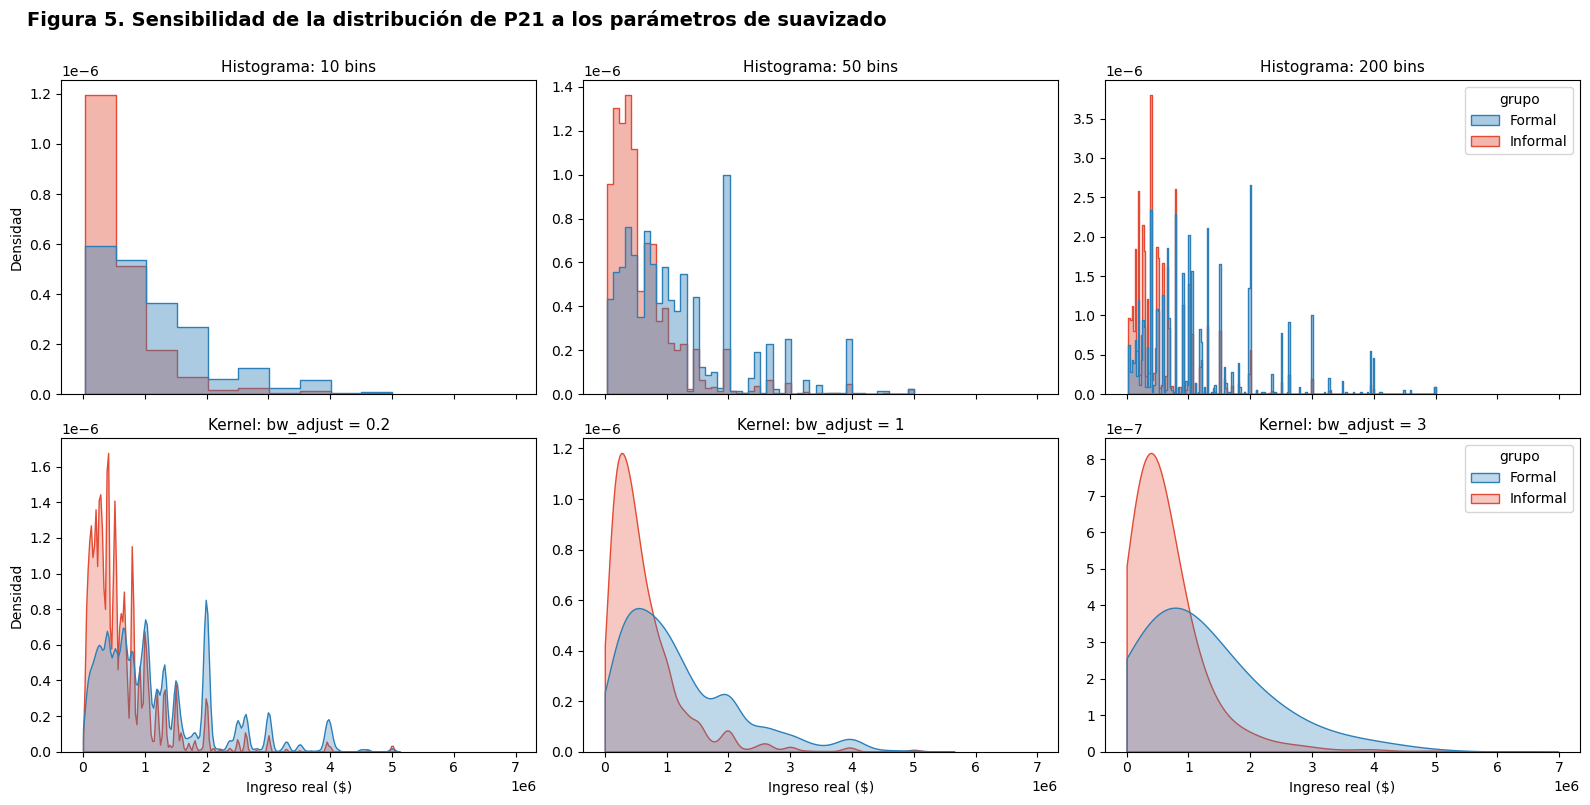

In [53]:
# Sensibilidad: mismo dato (P21 real), distintos parámetros de suavizado
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

for j, b in enumerate([10, 50, 200]):
    sns.histplot(data=datos_p21, x='P21_real', hue='grupo', stat='density',
                 common_norm=False, element='step', palette=colores,
                 alpha=0.4, bins=b, ax=axes[0, j], legend=(j == 2))
    axes[0, j].set_title(f"Histograma: {b} bins", fontsize=11)
    axes[0, j].set_xlabel(""); axes[0, j].set_ylabel("Densidad" if j == 0 else "")

for j, bw in enumerate([0.2, 1, 3]):
    sns.kdeplot(data=datos_p21, x='P21_real', hue='grupo', clip=(0, None),
                common_norm=False, fill=True, palette=colores,
                alpha=0.3, bw_adjust=bw, ax=axes[1, j], legend=(j == 2))
    axes[1, j].set_title(f"Kernel: bw_adjust = {bw}", fontsize=11)
    axes[1, j].set_xlabel("Ingreso real ($)"); axes[1, j].set_ylabel("Densidad" if j == 0 else "")

fig.suptitle("Figura 5. Sensibilidad de la distribución de P21 a los parámetros de suavizado",
             fontsize=14, fontweight='bold', x=0.02, ha='left', y=1.00)

plt.tight_layout()
plt.savefig('output/fig5_sensibilidad.png', dpi=150, bbox_inches='tight')
plt.show()
